# Initialisation
* `heating issue`
  * [ ] Is the power enough to let space reach setpoint?

    > This assumes a perfectly linear relationship between heating power and indoor air temperature. In reality, the building’s heat losses (ventilation, transmission) are temperature‑dependent – they increase as the indoor‑outdoor difference grows. If the test point (10 W/m²) results in a very small temperature rise (e.g., 0.1 K), the denominator is tiny, and the extrapolated demand can become enormous – but still finite. However, if the actual required demand is underestimated (e.g., because the slope is nonlinear), then supplying that underestimated power will not bring the air temperature to the setpoint.

* `parameter issue`
  * [ ] Indirect parameters:
    * JUN_5
        "_alpha"     :     12,
        "_beta"      :     0.02,
    * JUN_4
        "_alpha"     :     1,
        "_beta"      :     0.05,

  * [ ] Initial temperatures:
    > The operative temperature now uses t_s = t_m. This is a reasonable simplification but slightly underestimates radiative asymmetry. For most energy demand calculations it is acceptable.

  * [ ] Air capacitances:
      > Run a test with extreme ventilation changes (e.g., 0.3 → 5 ACH) and look for any non‑physical temperature oscillations. If they occur, increase c_air to, say, 5 * 1200 * room_vol. This can be done by setting a c_air_multiplier attribute in __init__.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
RC_SIMULATOR = "ETHlib"
if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system

case = RCCase(
    year=2023,
    loc_json              = Path("_json/location_params.json"),
    geo_json              = Path("_json/geo_params.json"),
    default_json          = Path("_json/default_params.json"),
    epw_path              = Path("../src/_base/epw/ED-TMYx.2023.epw"),
    occupancy_profile_csv = Path("ETHlib/auxiliary/schedules_el_OFFICE.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)

case.occupancy_profile = (
    pd.read_csv(Path("_data/bldg_LoD.csv"), usecols=["D"])
      .rename(columns={"D": "People"})
      .iloc[:8760]
      .reset_index(drop=True)
)

In [3]:
meter_path = "_data/Metering_ISO.csv"

meter_daily = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "D",
)

meter_hourly = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "h",
)

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# Test_2

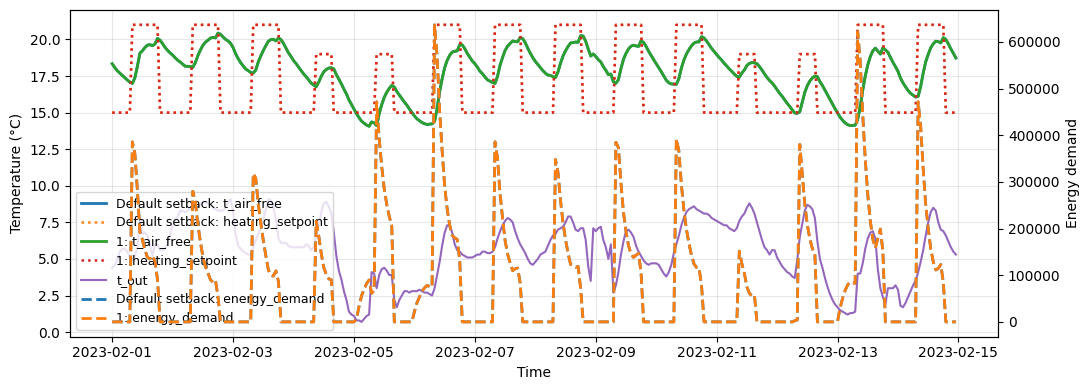

In [ ]:
import matplotlib.pyplot as plt

# -------------------------
# Contrast setup
# -------------------------
contrast_cases = {
    "Default setback": {},
    "1": {

        "max_heating_energy_per_floor_area":500
    },
}

start = "2023-02-01"
end = "2023-02-14"

debug_cols = [
    "energy_demand",
    "t_air_free",
    "heating_setpoint",
    "t_out",
]

samples = {}

# -------------------------
# Run contrast cases
# -------------------------
for case_name, sampled_params in contrast_cases.items():

    result, eui, debug = run_model_case(
        case=case,
        sampled_params=sampled_params,
        controller_mode="occupancy",
        rc_order="5R2C",
    )

    debug_df = debug.get_debug_dataframe()
    debug_df.index = result.index

    samples[case_name] = debug_df.loc[start:end, debug_cols].copy()

# -------------------------
# Plot contrast
# -------------------------
fig, ax1 = plt.subplots(figsize=(11, 4))

for case_name, sample in samples.items():
    ax1.plot(
        sample.index,
        sample["t_air_free"],
        linewidth=2,
        label=f"{case_name}: t_air_free",
    )

    ax1.plot(
        sample.index,
        sample["heating_setpoint"],
        linewidth=1.8,
        linestyle=":",
        label=f"{case_name}: heating_setpoint",
    )

# outdoor temperature only once
ax1.plot(
    samples["Default setback"].index,
    samples["Default setback"]["t_out"],
    linewidth=1.5,
    label="t_out",
)

ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Time")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

for case_name, sample in samples.items():
    ax2.plot(
        sample.index,
        sample["energy_demand"],
        linestyle="--",
        linewidth=2,
        label=f"{case_name}: energy_demand",
    )

ax2.set_ylabel("Energy demand")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
    fontsize=9,
)

plt.tight_layout()
plt.show()

# Test_1

In [5]:
start_date = "2023-02-01"
end_date = "2023-02-28"

In [6]:
result, eui, debug = run_model_case(
    case=case,
    sampled_params={},
    controller_mode="occupancy",
    rc_order="5R2C",
)
debug_df = debug.get_debug_dataframe()
debug_df.index = result.index
sample = debug_df.loc[
    start_date:end_date,
    ["energy_demand", "t_air_free", "heating_setpoint", "t_out"],
]